## 案例: 演示 KNN算法 识别图片, 即: 手写数字识别案例.

介绍:

    每张图片都是由 28 * 28 像素组成的, 即: 我们的csv文件中每一行都有 784个像素点, 表示图片(每个像素)的 颜色.
    最终构成图像.

#### 导包

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import joblib # 保存模型.
from collections import Counter

# 扩展: 忽略警告.
import warnings
warnings.filterwarnings('ignore', module='sklearn') # 参1: 忽略警告, 参2: 忽略的模块.

#### 1. 定义函数，接收用户传入的索引，展示该索引对应的图片

In [2]:
def show_digit(idx):
    # 1. 读取数据集，获取到源数据
    df = pd.read_csv('./data/手写数字识别.csv')
    #print(df)
    
    # 2. 判断传入的索引是否越界
    if idx < 0 or idx >= len(df) - 1:
        print('索引越界!')
        return
    
    # 3. 没有越界，正常获取数据
    x = df.iloc[:, 1:] # 第一个冒号：所有行      第二个冒号：从列索引1开始的所有列
    y = df.iloc[:, 0] # 所有行，列索引0
    
    # 4. 查看用户传入的索引对应的图片是几
    print(f'该图片对应的数字是：{y.iloc[idx]}')
    print(f'查看所有的标签的分布情况：{Counter(y)}')
    
    # 5. 查看下 传入的索引对应的图片 的形状
    print(x.iloc[idx].shape) # (784,),要转化成(28, 28)
    # print(x.iloc[idx].values) # 具体784个像素点   
    
    # 6. 把(784,)转化成(28, 28)
    x = x.iloc[idx].values.reshape(28, 28)
    # print(x) # 28 * 28像素点
    
    # 7. 具体的绘制灰度图的动作
    plt.imshow(x, cmap='gray')      # 灰度图
    plt.axis('off')        # 关闭坐标
    plt.show

#### 2. 定义函数，训练模型，并保存训练好的模型

In [3]:
def train_model():
    # 1. 加载数据集
    df = pd.read_csv('./data/手写数字识别.csv')
    
    # 2. 数据的预处理
    # 2.1 拆分出特征列
    x = df.iloc[:, 1:]      # 特征列
    # 2.2 拆分出标签列
    y = df.iloc[:, 0]       # 标签列
    # 2.3 打印特征和标签的形状
    print(f'x的形状：{x.shape}')        # (42000, 784)
    print(f'y的形状：{y.shape}')        #(42000,) 逗号后面没数说明是1
    # 2.4 对特征列(拆分前)进行归一化
    x = x / 255
    # 2.5 拆分训练集和测试集
    # 参1：特征列  参2：标签列  参3：测试集的比例  参4：随机种子  参5：参考y值进行抽取，保持标签的比例（数据均衡）
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=24, stratify=y)
    
    # 3. 模型训练
    # 3.1 创建模型对象
    estimator = KNeighborsClassifier(n_neighbors=3)
    # 3.2 模型训练
    estimator.fit(x_train, y_train)
    
    # 4. 模型评估
    print(f'准确率：{estimator.score(x_test, y_test)}')
    print(f'准确率：{accuracy_score(y_test, estimator.predict(x_test))}')
    
    # 5. 保存模型 
    # 参1：模型对象    参2：模型保存的路径
    joblib.dump(estimator, './saved_model/Handwriting_numerals_recognition.pkl') # pickle文件：Python(Pandas)独有的文件类型
    print('模型保存成功！')

#### 3. 定义函数，测试模型

In [19]:
def use_model():
    # 1. 加载图片
    x = plt.imread('./data/demo.png')       # 28*28像素
    # 核心：判断维度并分支处理
    if len(x.shape) == 3:  # 3维图（带通道）：自动降维为灰度图
        x = x.mean(axis=-1)  # 对最后一维（通道）求均值，兼容RGB(3通道)/RGBA(4通道)
    # 2维图：不做任何处理，直接跳过
    elif len(x.shape) == 2:
        pass
    else:
        print(f"不支持的图片维度：{x.shape}")
        return
    
    # 2. 绘制图片
    plt.axis('off')                     # 不显示坐标轴
    plt.imshow(x, cmap='gray')          # 灰度图
    plt.show()
    
    # 3. 加载模型
    estimator = joblib.load('./saved_model/Handwriting_numerals_recognition.pkl')
    
    # 4. 模型预测
    # 4.1 查看数据集转换
    print(x.shape)                      # (28, 28)
    print(x.reshape(1, 784).shape)      # 转成(1, 784)
    print(x.reshape(1, -1).shape)       # 效果等同于(1, 784),语法糖
    # 4.2 具体的转换动作，记得归一化
    # x = x.reshape(1, -1) / 255        # 除255可能会预测失败
    x = x.reshape(1, -1)                # 不用除255，已经自动归一化
    # 4.3 模型预测
    y_pred = estimator.predict(x)
    
    # 5. 打印预测结果
    print(f'预测值为：{y_pred}')

#### 4. 测试

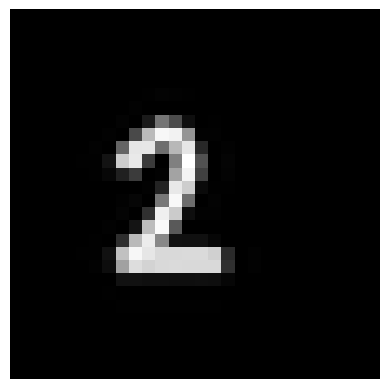

(28, 28)
(1, 784)
(1, 784)
预测值为：[2]


In [20]:
if __name__ == '__main__':
    # 绘制数字
    # show_digit(9)
    
    # 训练模型，并保存模型
    # train_model()
    
    # 模型预测（使用模型）
    use_model()